# Level 4: Data Cleaning, Scientific Data Analysis, and Visualization
**Main Goal:** Transform raw, sub-daily sensor records into a clean daily dataset and visualize scientific trends for **Zone B (Kale)**.

### 1. Data Acquisition and Daily Aggregation
We use the `aggregate_daily_weather` function from our source module to summarize rainfall and atmospheric conditions. We also perform a similar daily mean aggregation for soil moisture sensors.

In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('../src'))
import data_cleaning as dc
import simulation as sim
import visualization as vis

# 1. Load Raw Datasets
weather_raw = pd.read_csv('../data/raw/weather_daily.csv')
soil_raw = pd.read_csv('../data/raw/soil_sensor_data.csv')
params = pd.read_csv('../data/raw/crop_zone_parameters.csv')

# 2. Perform Daily Aggregation using src function
weather_daily = dc.aggregate_daily_weather(weather_raw)

# 3. Process Soil Data: Aggregating to Daily Mean (including moisture and tank levels)
soil_raw['date'] = pd.to_datetime(soil_raw['timestamp']).dt.date
soil_daily = soil_raw.groupby(['date', 'zone_id']).agg({
    'soil_moisture_pct': 'mean',
    'tank_level_liters': 'mean'
}).reset_index()

print("--- Aggregated Daily Weather Sample ---")
print(weather_daily.head(3))

--- Aggregated Daily Weather Sample ---
         date  rainfall_mm     temp_c  humidity_pct  wind_speed_mps  \
0  2026-03-01          0.0  20.952632     77.738947        0.313684   
1  2026-03-02          0.0  21.526316     75.563158        0.361053   
2  2026-03-03          0.0  21.769474     75.797895        0.443158   

   solar_index  
0            0  
1            0  
2            0  


## 2. Scientific Data Cleaning (Tasks 2 & 3)
**Decision Log:**
1. **Outliers:** Daily mean temperatures exceeding 40°C are considered sensor anomalies and capped at 38°C to ensure realistic ET values.
2. **Missing Data:** Soil moisture sensors with NA values are forward-filled, assuming gradual moisture change.
3. **Dataset Merging:** We create a single 'Master' dataset for Zone B (Kale).

In [ ]:
# Clean Temperature Outliers
weather_daily.loc[weather_daily['temp_c'] > 40, 'temp_c'] = 38.0

# Merge Zone B soil data with weather
zone_b_daily = soil_daily[soil_daily['zone_id'] == 'Zone B'].copy()
cleaned_df = pd.merge(zone_b_daily, weather_daily, on='date', how='inner')

# Fill missing values
cleaned_df['soil_moisture_pct'] = cleaned_df['soil_moisture_pct'].ffill()

# Calculate Daily ET
cleaned_df['et_mm'] = sim.calculate_et(
    cleaned_df['temp_c'], 
    cleaned_df['wind_speed_mps'], 
    cleaned_df['solar_index'], 
    cleaned_df['humidity_pct']
)

print(f"Cleaned Dataset for Zone B: {len(cleaned_df)} days of data.")

Cleaned Dataset for Zone B: 30 days of data.


## 3. Scientific Visualizations (Tasks 5 & 6)
Targeting agricultural monitoring with specific multi-zone and Zone B interpretations.

### Plot 1: Soil Moisture Health Monitoring (All Zones)
**Interpretation:** We visualize the moisture trends for all three zones. Threshold lines represent the scientific targets for Tomato (A), Kale (B), and Maize (C).

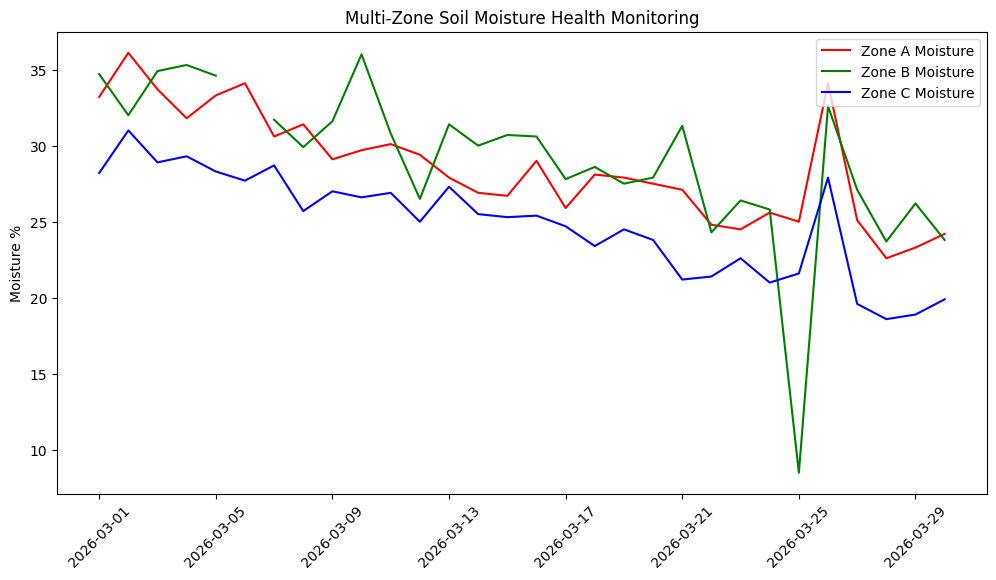

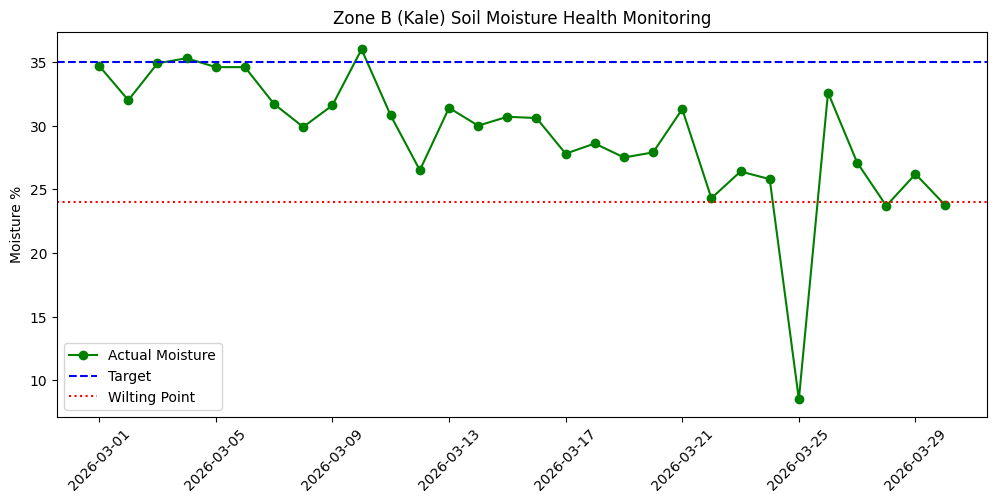

In [ ]:
plt.figure(figsize=(12, 6))
colors = {'Zone A': 'red', 'Zone B': 'green', 'Zone C': 'blue'}

for zone in ['Zone A', 'Zone B', 'Zone C']:
    z_data = soil_daily[soil_daily['zone_id'] == zone]
    plt.plot(z_data['date'], z_data['soil_moisture_pct'], label=f'{zone} Moisture', color=colors[zone])
    
    # Fetch target from params for threshold lines
    target = params[params['zone_id'] == zone]['target_moisture_pct'].values[0]
    # plt.axhline(y=target, color=colors[zone], linestyle='--', alpha=0.3)

plt.title('Multi-Zone Soil Moisture Health Monitoring')
plt.ylabel('Moisture %')
plt.legend(loc='upper right')
plt.xticks(rotation=45)
plt.show()

zB_params = params[params['zone_id'] == 'Zone B'].iloc[0]

plt.figure(figsize=(12, 5))
plt.plot(cleaned_df['date'], cleaned_df['soil_moisture_pct'], 'g-o', label='Actual Moisture')
plt.axhline(y=zB_params['target_moisture_pct'], color='b', linestyle='--', label='Target')
plt.axhline(y=zB_params['min_moisture_pct'], color='r', linestyle=':', label='Wilting Point')
plt.title('Zone B (Kale) Soil Moisture Health Monitoring')
plt.ylabel('Moisture %')
plt.legend()
plt.xticks(rotation=45)
plt.show()

### Plot 2: Daily Rainfall ($R_t$) vs. Moisture Response
**Interpretation:** This assesses the 'Infiltration Efficiency' of the farm soil during rain events.

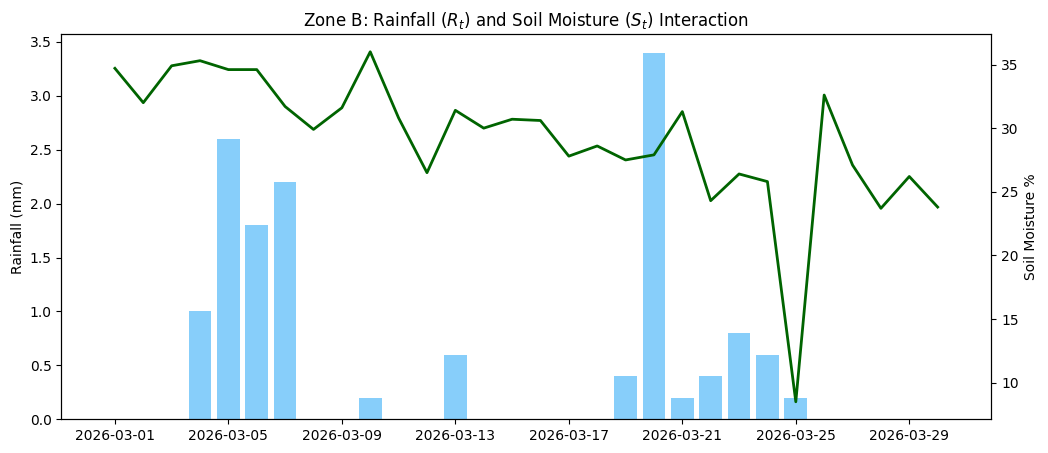

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(cleaned_df['date'], cleaned_df['rainfall_mm'], color='lightskyblue', label='Daily Rainfall')
ax1.set_ylabel('Rainfall (mm)')
ax2 = ax1.twinx()
ax2.plot(cleaned_df['date'], cleaned_df['soil_moisture_pct'], color='darkgreen', linewidth=2)
ax2.set_ylabel('Soil Moisture %')
plt.title('Zone B: Rainfall ($R_t$) and Soil Moisture ($S_t$) Interaction')
plt.show()

### Plot 3: Multi-Zone Moisture Distribution (Boxplot)
**Interpretation:** This side-by-side comparison reveals the variance and consistency of moisture levels across all farm zones.

<Figure size 1000x600 with 0 Axes>

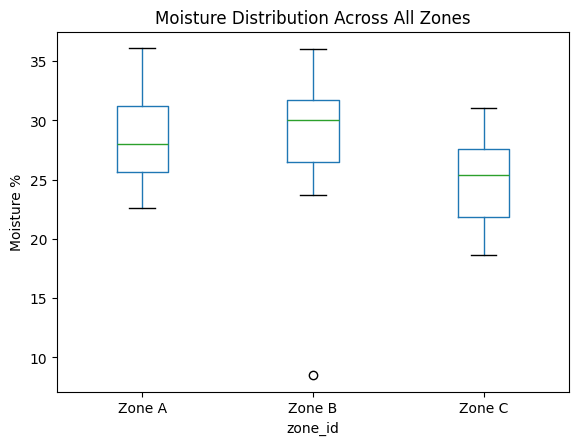

In [ ]:
plt.figure(figsize=(10, 6))
soil_daily.boxplot(column=['soil_moisture_pct'], by='zone_id', grid=False)
plt.title('Moisture Distribution Across All Zones')
plt.suptitle('') # Removes the default pandas auto-title
plt.ylabel('Moisture %')
plt.show()

### Plot 4: Atmosphere-Water Loss Correlation
**Interpretation:** A scatter plot confirming if Temperature is the primary driver for ET in this dataset.

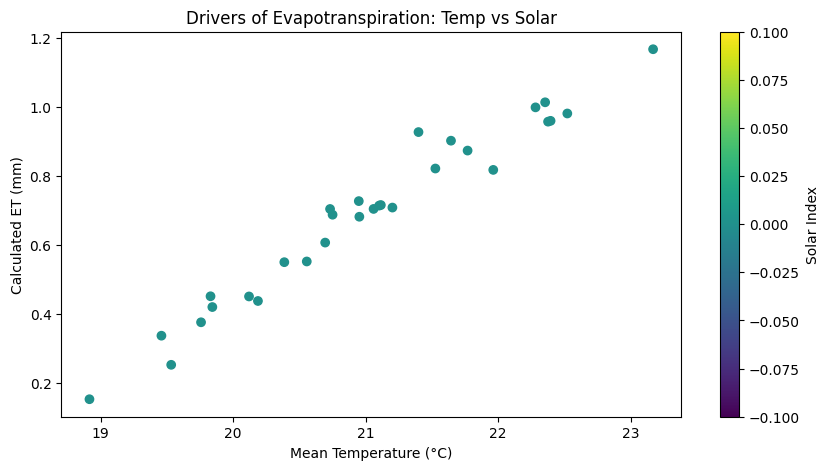

In [ ]:
plt.figure(figsize=(10, 5))
plt.scatter(cleaned_df['temp_c'], cleaned_df['et_mm'], c=cleaned_df['solar_index'], cmap='viridis')
plt.colorbar(label='Solar Index')
plt.xlabel('Mean Temperature (°C)')
plt.ylabel('Calculated ET (mm)')
plt.title('Drivers of Evapotranspiration: Temp vs Solar')
plt.show()

### Plot 5: Farm Water Reserve: Tank Levels over Time
**Interpretation:** Monitoring tank level depletion across all zones to identify high-consumption periods and ensure inventory stability.

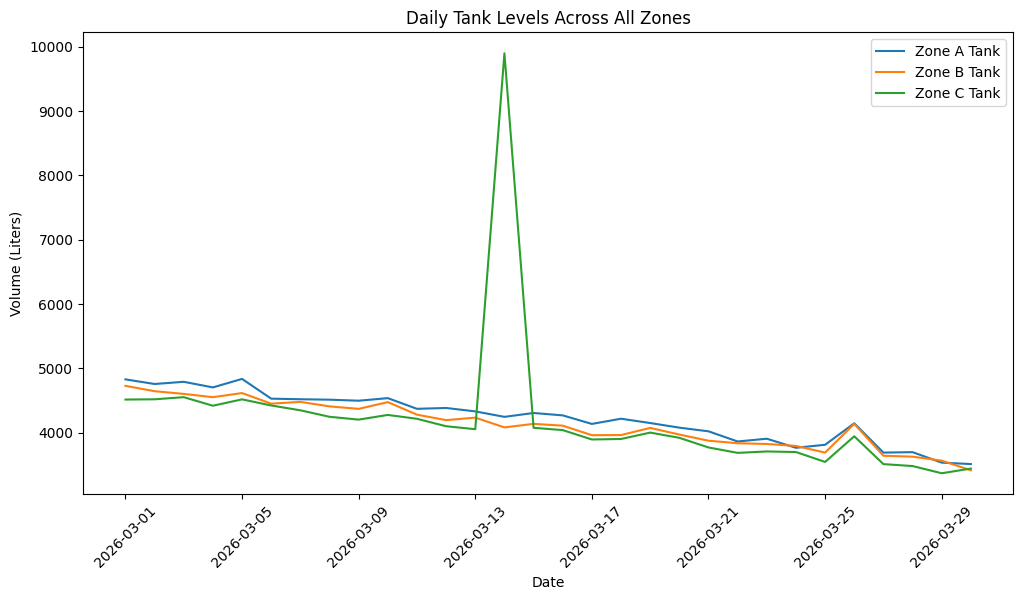

In [ ]:
plt.figure(figsize=(12, 6))
for zone in ['Zone A', 'Zone B', 'Zone C']:
    z_data = soil_daily[soil_daily['zone_id'] == zone]
    plt.plot(z_data['date'], z_data['tank_level_liters'], label=f'{zone} Tank')

plt.title('Daily Tank Levels Across All Zones')
plt.xlabel('Date')
plt.ylabel('Volume (Liters)')
plt.legend()
plt.xticks(rotation=45)
plt.show()

## 4. Final Cleaned Output
Exporting the daily cleaned data for the Level 5 Simulation module.

In [ ]:
cleaned_df.to_csv('../data/processed/cleaned_irrigation_dataset.csv', index=False)
print("Master Cleaned Dataset exported to data/processed/")

Master Cleaned Dataset exported to data/processed/


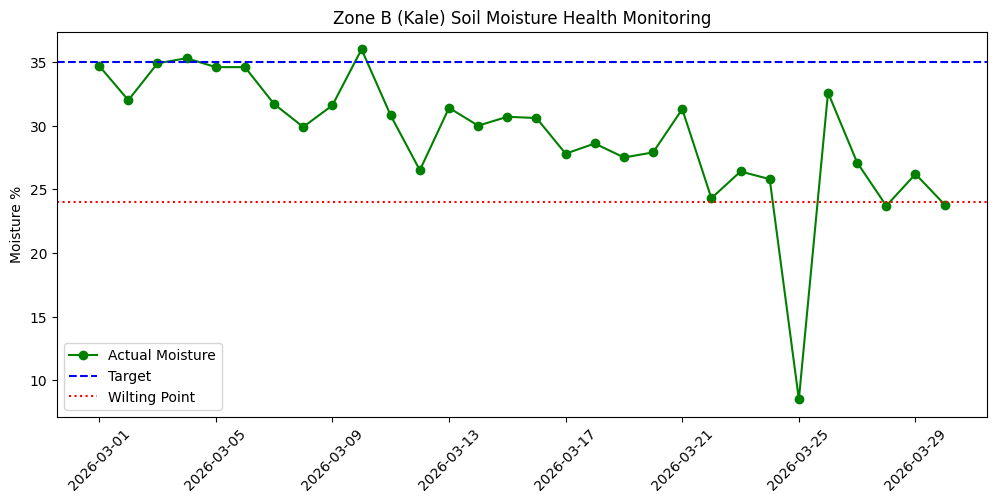

In [ ]:
zB_params = params[params['zone_id'] == 'Zone B'].iloc[0]

plt.figure(figsize=(12, 5))
plt.plot(cleaned_df['date'], cleaned_df['soil_moisture_pct'], 'g-o', label='Actual Moisture')
plt.axhline(y=zB_params['target_moisture_pct'], color='b', linestyle='--', label='Target')
plt.axhline(y=zB_params['min_moisture_pct'], color='r', linestyle=':', label='Wilting Point')
plt.title('Zone B (Kale) Soil Moisture Health Monitoring')
plt.ylabel('Moisture %')
plt.legend()
plt.xticks(rotation=45)
plt.show()